# PENGWIN, semana 10: fragmentos, distancia, SAM y latencia

Proyecto Integrador Corte 2, Analítica de Datos, UAO 2026-2. Uso exclusivamente académico.

Contenido:

1. Qué hicimos en la semana
2. Modelo v2
3. Por qué no se separaban los fragmentos
4. Separación por distancia
5. Resultados por fragmento
6. Distancia de separación en mm
7. SAM como línea base
8. Latencia
9. Qué aporta cada parte de la red
10. Pendientes

Igual que el notebook de sustentación, lee los resultados guardados en `reports/`. Si están el caché (`PENGWIN_CACHE_DIR`) y los checkpoints, rehace la figura de ejemplo.

In [1]:
import json
import os
import sys
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.precision", 3)


def find_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "03_src" / "pengwin").is_dir():
            return p
    raise FileNotFoundError("No se encontró la raíz del repositorio")


ROOT = find_root()
sys.path.insert(0, str(ROOT / "03_src"))
REP = ROOT / "reports"
FIG = REP / "figures" / "semana10"
FIG.mkdir(parents=True, exist_ok=True)
CACHE = Path(os.environ.get("PENGWIN_CACHE_DIR", ROOT / "data_processed"))
CKPT = ROOT / "checkpoints" / "v2_last" / "best.pth"
try:
    import torch
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False
LIVE = HAS_TORCH and CKPT.exists() and (CACHE / "084" / "meta.json").exists()

C = {"SA": "#2a78d6", "LI": "#eb6834", "RI": "#1baf7a"}
INK, INK2, MUTED, GRID, AXIS, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
mpl.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 9,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 8, "font.size": 9, "lines.linewidth": 2,
})


def savefig(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=150, bbox_inches="tight")


def read_json(p):
    return json.loads(Path(p).read_text(encoding="utf-8"))

## 1. Qué hicimos en la semana

La semana 9 dejó un modelo que dice qué píxeles son de cada hueso. Esta semana pasamos a los **fragmentos**:

1. El modelo recorre todos los cortes del paciente y se arma el volumen de regiones y bordes de fractura.
2. Cada hueso se divide en fragmentos (sección 4).
3. Todo se devuelve al tamaño original del `.mha`.
4. Se mide la distancia de cada fragmento al principal en mm, con `distance_transform_edt` y el spacing del header.
5. Se compara contra el ground truth, contra SAM, y se mide la latencia.

## 2. Modelo v2

Entrenamos un segundo modelo en ANTON, de 40 épocas, con cuatro cambios:

- **Borde de fractura en 3D:** antes se calculaba dentro de cada corte y no veía los contactos entre cortes.
- **Dropout espacial** (`Dropout2d`, p = 0,1) en los bloques 3 y 4 y en el decodificador. Apaga canales completos.
- **γ aprendible** en el CBAM y en el cuello, para medir cuánto se usa cada parte (sección 9).
- **λ recalibrados**, porque la pérdida de borde cambió.

Comparación en test con las métricas de la semana 9:

In [2]:
ev = {n: read_json(REP / "eval" / f"{r}_test.json")["metricas"] for r, n in (("base", "Base"), ("v2_last", "v2"))}
keys = ["mAP@0.50", "mAP@[.50:.95]", "IoU_promedio", "dice_hueso", "dice_SA", "cls_f1_macro"]
pd.DataFrame({n: {k: m[k] for k in keys} for n, m in ev.items()}).round(3)

,Base,v2
mAP@0.50,0.977,0.980
mAP@[.50:.95],0.841,0.864
IoU_promedio,0.911,0.919
dice_hueso,0.968,0.971
dice_SA,0.954,0.961
cls_f1_macro,0.993,0.993


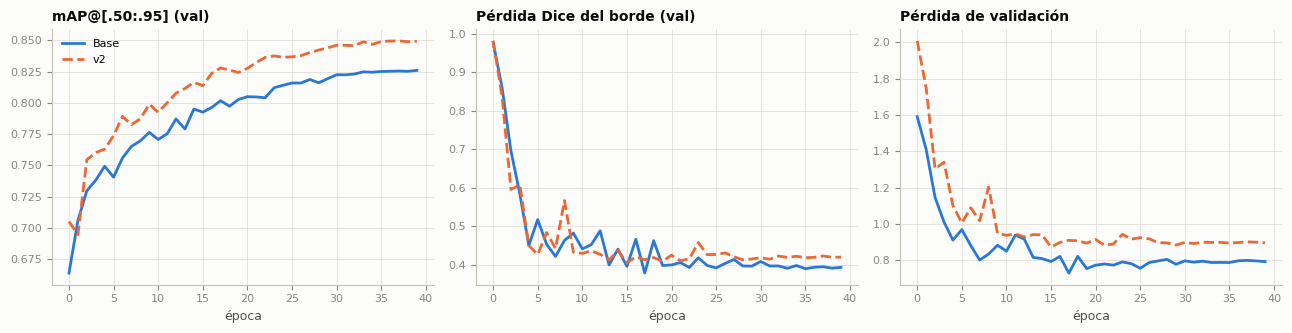

In [3]:
H = {n: pd.read_csv(REP / "train" / f"{r}_history.csv") for r, n in (("base", "Base"), ("v2", "v2"))}
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, (col, title) in zip(axes, (("mAP@[.50:.95]", "mAP@[.50:.95] (val)"), ("val_edge_dice", "Pérdida Dice del borde (val)"),
                                   ("val_total", "Pérdida de validación"))):
    for (n, h), (color, ls) in zip(H.items(), ((C["SA"], "-"), (C["LI"], "--"))):
        ax.plot(h.epoch, h[col], color=color, ls=ls, label=n)
    ax.set_title(title, loc="left", fontsize=10)
    ax.set_xlabel("época")
axes[0].legend()
fig.tight_layout()
savefig(fig, "01_curvas_base_v2")
plt.show()

v2 afina mejor las cajas (mAP@[.5:.95] de 0,841 a 0,864 en test). Las pérdidas de validación no se comparan directo entre los dos, porque el objetivo del borde cambió (3D, con otro peso).

## 3. Por qué no se separaban los fragmentos

Al principio separábamos cada hueso así: quitar los píxeles de borde y tomar los pedazos que quedaran. Con eso, casi ningún fragmento secundario salía separado (12 % con el modelo base, 10 % con v2).

Para encontrar la causa probamos cruzando lo predicho con lo real:

| Región usada | Borde usado | Secundarios recuperados |
|---|---|---|
| predicha | predicho | 8 % |
| predicha | real | 11 % |
| real | predicho | 12 % |
| real | real | 71 % |

Fallan las dos cosas a la vez:
- el borde predicho solo encuentra el 15 % del borde real;
- la región predicha "rellena" las grietas entre fragmentos y los vuelve a unir.

## 4. Separación por distancia

En vez de depender solo del borde, buscamos el **centro** de cada fragmento:

1. En cada hueso se calcula a cuántos mm está cada vóxel del borde más cercano (`distance_transform_edt`).
2. Las zonas a más de 5 mm del borde son semillas, y cada semilla es un fragmento. Las grietas y las uniones delgadas nunca llegan a 5 mm, así que separan aunque la red las haya rellenado.
3. Un watershed reparte el resto del hueso entre las semillas.
4. El fragmento más grande es el principal.

Los 5 mm se eligieron en **validación** (no en test):

| Método | Profundidad de semilla | Secundarios recuperados | Dice fragmento |
|---|---|---|---|
| solo borde | — | 1,8 % | 0,531 |
| distancia | 2 mm | 31,0 % | 0,638 |
| distancia | 3 mm | 46,4 % | 0,705 |
| distancia | 4 mm | 61,3 % | 0,765 |
| **distancia** | **5 mm** | **67,3 %** | **0,790** |
| distancia | 6 mm | 59,5 % | 0,764 |
| distancia | 8 mm | 33,3 % | 0,622 |

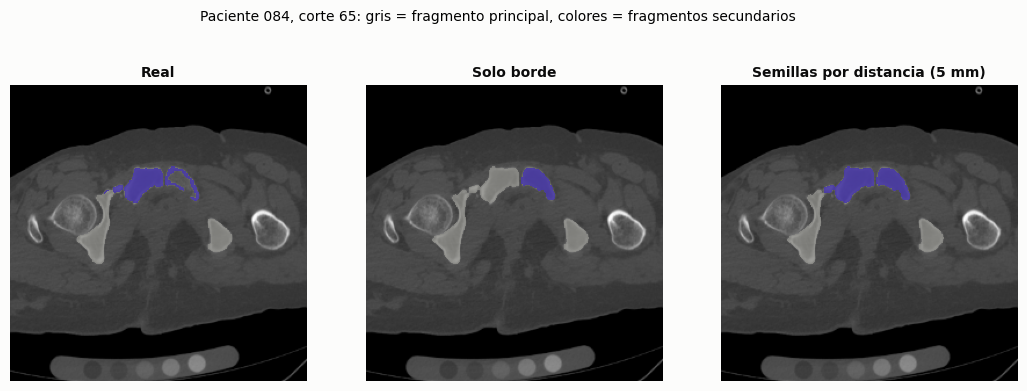

In [4]:
ej_png = FIG / "02_ejemplo_fragmentos.png"
if LIVE:
    from matplotlib.colors import ListedColormap
    from pengwin.data.slice_cache import load_case_cache
    from pengwin.inference.volume import predict_case
    from pengwin.models.pengwin_net import PengwinNet
    from pengwin.postprocess.instances import separate_instances
    from pengwin.utils.config import load_config

    dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ck = torch.load(CKPT, map_location="cpu", weights_only=False)
    model = PengwinNet(ck["cfg"]["model"]).to(dev).eval()
    model.load_state_dict(ck["model"])
    pp = load_config(ROOT / "configs" / "base.yaml")["postprocess"]
    case = "084"
    pred = predict_case(model, CACHE, case, ck["cfg"], dev)
    image, label, meta = load_case_cache(CACHE / case)
    sp = (meta["spacing_zyx"][0], meta["pixel_mm"], meta["pixel_mm"])
    solo_borde = separate_instances(pred["semantic"], pred["edge"], sp, 0.5, method="edge")
    distancia = separate_instances(pred["semantic"], pred["edge"], sp, pp["edge_threshold"], method="edt", seed_depth_mm=pp["seed_depth_mm"])
    lab = np.asarray(label)
    # corte con más fragmentos secundarios en el GT
    z = int(np.argmax([((lab[k] % 10) > 1).sum() for k in range(lab.shape[0])]))
    # color: principal gris, secundarios en violeta / rosa / amarillo
    cmap = ListedColormap([(0, 0, 0, 0), (0.55, 0.55, 0.53, 0.75), (0.29, 0.23, 0.65, 0.9), (0.91, 0.48, 0.64, 0.9),
                           (0.93, 0.63, 0.0, 0.9), (0.2, 0.2, 0.2, 0.9)])
    rank = lambda L: np.where(L > 0, np.minimum((L - 1) % 10 + 1, 5), 0)
    fig, ax = plt.subplots(1, 3, figsize=(13, 4.6))
    for a, (L, t) in zip(ax, ((lab, "Real"), (solo_borde, "Solo borde"), (distancia, "Semillas por distancia (5 mm)"))):
        a.imshow(np.asarray(image[z]), cmap="gray")
        a.imshow(rank(L[z]), cmap=cmap, vmin=0, vmax=5, interpolation="nearest")
        a.set_title(t, fontsize=10)
        a.axis("off")
    fig.suptitle(f"Paciente {case}, corte {z}: gris = fragmento principal, colores = fragmentos secundarios", fontsize=10)
    savefig(fig, "02_ejemplo_fragmentos")
    plt.show()
elif ej_png.exists():
    display(Image(filename=str(ej_png), width=950))

## 5. Resultados por fragmento

Test: 15 pacientes, 84 fragmentos reales (45 principales y 39 secundarios). Cada fragmento real se empareja con el predicho que más se le parece, y si no tiene pareja cuenta como Dice 0.

In [5]:
rows = {}
for r, name in (("base_test", "Base, solo borde"), ("v2_test", "v2, solo borde"),
                ("base_test_edt", "Base, distancia"), ("v2_last_test_edt", "v2, distancia")):
    f = REP / "fragments" / f"{r}.json"
    if f.exists():
        g = read_json(f)["global"]
        rows[name] = {"Dice fragmento": g["dice_fragmento"], "IoU fragmento": g["iou_fragmento"],
                      "Dice principal": g["dice_principal"], "Dice secundario": g["dice_secundario"],
                      "Secundarios recuperados %": g["recuperados_secundarios_%"]}
tabla = pd.DataFrame(rows)
tabla["Objetivo"] = ["≥ 0.85", "≥ 0.70", "", "", ""]
tabla.round(3)

,"Base, solo borde","v2, solo borde","Base, distancia","v2, distancia",Objetivo
Dice fragmento,0.545,0.533,0.717,0.725,≥ 0.85
IoU fragmento,0.505,0.493,0.657,0.671,≥ 0.70
Dice principal,0.921,0.920,0.920,0.930,
Dice secundario,0.111,0.086,0.483,0.489,
Secundarios recuperados %,12.821,10.256,51.282,51.282,


In [6]:
f = pd.read_csv(REP / "fragments" / "v2_last_test_edt_fragmentos.csv")
f["tamaño"] = pd.cut(f.volumen_cm3, [0, 5, 20, np.inf], labels=["< 5 cm³", "5-20 cm³", "> 20 cm³"])
f["tipo"] = np.where(f.es_principal, "principal", "secundario")
f.groupby(["tipo", "tamaño"], observed=True).agg(n=("dice", "size"), dice=("dice", "mean"), recuperados=("recuperado", "mean")).round(3)

n   dice  recuperados
tipo       tamaño                          
principal  > 20 cm³  45  0.930        1.000
secundario < 5 cm³    7  0.000        0.000
           5-20 cm³  13  0.506        0.538
           > 20 cm³  19  0.657        0.684

Los fragmentos principales salen bien (Dice 0,93). El Dice por fragmento (0,725) todavía no llega al objetivo de 0,85 por los secundarios: recuperamos la mitad, y los menores de 5 cm³ no reciben semilla con 5 mm de profundidad.

## 6. Distancia de separación en mm

Se mide igual en la predicción y en el ground truth: la distancia mínima de cada secundario al principal de su hueso. Si la distancia es menor o igual que la diagonal del vóxel, el fragmento está "en contacto".

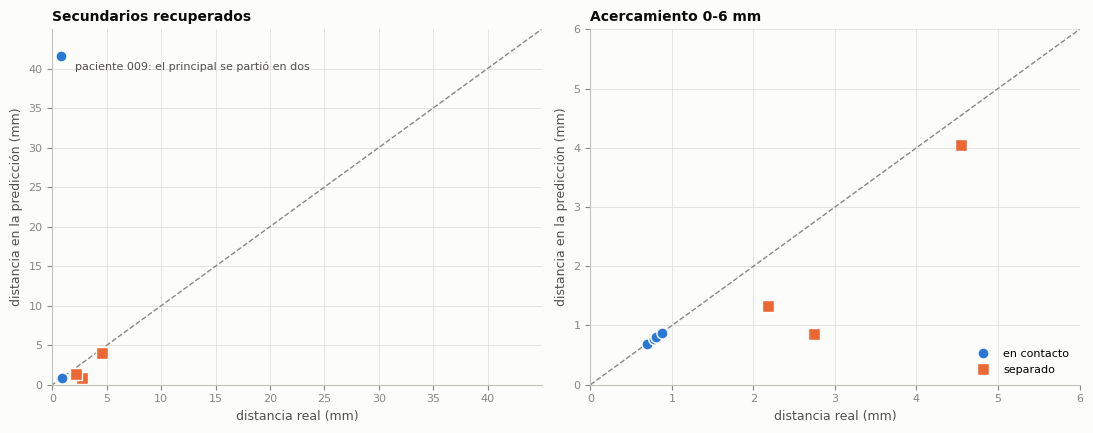

20 secundarios medidos | error medio 2.20 mm | mediana 0.00 mm | sin el caso atípico 0.17 mm


In [7]:
d = pd.read_csv(REP / "fragments" / "v2_last_test_edt_distancias.csv")
dm = d[d.medido]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, lim in zip(axes, (max(dm.dist_gt_mm.max(), dm.dist_pred_mm.max()) * 1.08, 6)):
    ax.plot([0, lim], [0, lim], color=MUTED, lw=1, ls="--")
    for contacto, marker, name in ((True, "o", "en contacto"), (False, "s", "separado")):
        s = dm[dm.contacto_gt == contacto]
        ax.plot(s.dist_gt_mm, s.dist_pred_mm, marker, ms=8, color=C["SA"] if contacto else C["LI"], mec="white",
                label=name, ls="none")
    ax.set(xlabel="distancia real (mm)", ylabel="distancia en la predicción (mm)", xlim=(0, lim), ylim=(0, lim))
peor = dm.loc[dm.error_mm.abs().idxmax()]
axes[0].annotate(f"paciente {int(peor.case_id):03d}: el principal se partió en dos", (peor.dist_gt_mm, peor.dist_pred_mm),
                 xytext=(10, -4), textcoords="offset points", fontsize=8, color=INK2, va="top")
axes[0].set_title("Secundarios recuperados", loc="left", fontsize=10)
axes[1].set_title("Acercamiento 0-6 mm", loc="left", fontsize=10)
axes[1].legend()
fig.tight_layout()
savefig(fig, "03_distancias")
plt.show()
e = dm.error_mm.abs()
print(f"{len(dm)} secundarios medidos | error medio {e.mean():.2f} mm | mediana {e.median():.2f} mm | "
      f"sin el caso atípico {e.nsmallest(len(e) - 1).mean():.2f} mm")

Casi todos los puntos caen sobre la diagonal. El único error grande es un paciente donde el modelo partió en dos el fragmento principal, y el secundario se midió contra el pedazo equivocado. Así se ve cómo un error de la segmentación pasa a la medida.

## 7. SAM como línea base

SAM (ViT-B, sin entrenar en nuestros datos) recibe el mismo corte y, como prompt, la caja que predijo nuestro detector. Se compara contra la segmentación por hueso del modelo propio.

In [8]:
sam = read_json(REP / "sam" / "base_test.json")
display(pd.DataFrame(sam["resultados"]).T[["dice", "iou", "dice_SA", "dice_LI", "dice_RI"]].round(3))
print(f"{sam['cortes_con_hueso']} cortes de test · SAM tarda {sam['ms_sam_por_corte']:.0f} ms por corte")

,dice,iou,dice_SA,dice_LI,dice_RI
propio,0.968,0.938,0.954,0.975,0.974
SAM + caja predicha,0.908,0.832,0.863,0.927,0.932
SAM + caja GT,0.908,0.832,0.866,0.925,0.931


3765 cortes de test · SAM tarda 417 ms por corte


El modelo propio le gana a SAM por 6 puntos de Dice, y por 9 en el sacro. SAM rinde igual con nuestras cajas que con las reales, así que el detector no es lo que lo limita.

## 8. Latencia

Un corte a la vez (como en el slider del dashboard), contando el modelo, la decodificación de cajas y la NMS.

In [9]:
lat = read_json(REP / "latency" / "base.json")
display(pd.DataFrame({"CPU fp32": lat["cpu_fp32"], "GPU fp32": lat["gpu_fp32"], "GPU AMP": lat["gpu_amp"]}).T[["media_ms", "p50_ms", "p95_ms"]].round(1))
print(f"GPU: {lat['gpu']} · volumen completo ({lat['cortes_volumen']} cortes): {lat['gpu_volumen_completo_s']:.1f} s")

,media_ms,p50_ms,p95_ms
CPU fp32,101.8,100.7,113.6
GPU fp32,10.2,10.5,13.4
GPU AMP,12.8,12.2,15.5


GPU: NVIDIA GeForce RTX 3060 Laptop GPU · volumen completo (401 cortes): 3.4 s


## 9. Qué aporta cada parte de la red

Dos medidas sobre v2:

- **γ:** un peso que la red aprende en cada componente. Si queda cerca de 0, el componente casi no se usa.
- **Apagar el componente:** se quita en inferencia y se mide cuánto cae el modelo.

In [10]:
ct = read_json(REP / "contribucion" / "v2_last.json")
caida = pd.DataFrame(ct["caida_por_knockout"]).T[["mAP@[.50:.95]", "dice_hueso", "dice_SA"]]
caida.index = [i.replace("sin ", "") for i in caida.index]
g = pd.Series(ct["gammas"], name="γ")
caida.join(g).round(3)

,mAP@[.50:.95],dice_hueso,dice_SA,γ
residual b1,-0.042,-0.006,-0.005,0.248
residual b2,-0.027,-0.003,-0.004,0.216
residual b3,-0.033,-0.001,0.001,0.210
CBAM b3,-0.002,-0.000,-0.001,0.182
residual b4,-0.513,-0.176,-0.248,0.322
CBAM b4,-0.068,-0.011,-0.020,-1.898
contexto C4 en P3,-0.793,-0.335,-0.474,NaN
contexto 2.5D,-0.043,-0.019,-0.021,NaN


- El CBAM del bloque 3 casi no se usa: γ ≈ 0,18, y apagarlo no cambia nada.
- El del bloque 4 sí se usa (γ ≈ −1,9).
- Lo indispensable es el bloque residual 4 y el contexto profundo que entra al cuello.

Apagar una parte mide cuánto **depende** la red de ella, no cuánto **aporta**. En la semana 9, el modelo entrenado sin CBAM llegó al mismo resultado que el que lo tenía.

## 10. Pendientes

- Recuperar los fragmentos pequeños (< 5 cm³).
- Mejorar la cabeza de borde, que sigue sobreajustando.
- HD95 y ASSD (opcionales, puntos extra).
- Semana 11: visualizadores 2 y 3, dashboard en Streamlit, túnel de Cloudflare, model card.

Comandos:

```powershell
python scripts/build_slice_cache.py   --cache-dir D:/PENGWIN/data_processed --edges-only
python scripts/evaluate_fragments.py  --ckpt checkpoints/v2_last/best.pth --cache-dir D:/PENGWIN/data_processed --data-dir D:/PENGWIN/01_data --tag _edt
python scripts/sam_baseline.py        --ckpt checkpoints/base/best.pth --cache-dir D:/PENGWIN/data_processed --sam-ckpt D:/PENGWIN/sam/sam_vit_b_01ec64.pth
python scripts/latency.py             --ckpt checkpoints/base/best.pth --cache-dir D:/PENGWIN/data_processed
python scripts/component_contribution.py --ckpt checkpoints/v2_last/best.pth --cache-dir D:/PENGWIN/data_processed
```